# Лабораторная №5

Детекция номеров на изображениях с использованием `SVHN format 1` и предобученного детектора `Faster R-CNN`.


In [1]:
import os
import random
from dataclasses import dataclass
from pathlib import Path
from typing import List, Dict

os.environ.setdefault("MPLCONFIGDIR", str(Path(".mplconfig").resolve()))
os.environ.setdefault("TORCH_HOME", str(Path(".cache/torch").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)
Path(os.environ["TORCH_HOME"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageDraw
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_320_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import box_iou
from torchvision.transforms import functional as TF

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")
device


Using device: cuda


device(type='cuda')

## 1. Конфиг


In [22]:
@dataclass
class Config:
    svhn_root: Path = Path("data/svhn")
    city_photos_dir: Path = Path("/content/drive/MyDrive/colab")
    image_size: int = 320
    batch_size: int = 4
    num_workers: int = 0
    epochs: int = 5
    lr: float = 1e-4
    weight_decay: float = 1e-4
    train_subset: int | None = None
    test_subset: int | None = None
    val_size_from_train: float = 0.15
    score_threshold: float = 0.5
    iou_threshold: float = 0.5

config = Config()
config


Config(svhn_root=PosixPath('data/svhn'), city_photos_dir=PosixPath('/content/drive/MyDrive/colab'), image_size=320, batch_size=4, num_workers=0, epochs=5, lr=0.0001, weight_decay=0.0001, train_subset=None, test_subset=None, val_size_from_train=0.15, score_threshold=0.5, iou_threshold=0.5)

In [4]:
def _read_h5_scalar(dataset, ref):
    value = dataset[ref][()]
    if isinstance(value, np.ndarray):
        value = value.squeeze()
    return float(value)


def _read_h5_values(dataset, value):
    if isinstance(value, np.ndarray) and value.shape == (1, 1):
        return [float(value.squeeze())]
    if isinstance(value, np.ndarray) and value.dtype.kind in {"O", "u"}:
        return [_read_h5_scalar(dataset, ref) for ref in value.squeeze()]
    if isinstance(value, np.ndarray):
        return [float(x) for x in value.squeeze().tolist()]
    return [float(value)]


def parse_svhn_digit_struct(split_dir: Path) -> List[Dict]:
    split_dir = Path(split_dir)
    mat_path = split_dir / "digitStruct.mat"

    records = []
    with h5py.File(mat_path, "r") as f:
        names_ds = f["digitStruct/name"]
        bbox_ds = f["digitStruct/bbox"]

        for idx in range(len(names_ds)):
            name_ref = names_ds[idx][0]
            image_name = ''.join(chr(c[0]) for c in f[name_ref][:])
            bbox_ref = bbox_ds[idx][0]
            bbox_group = f[bbox_ref]

            lefts = _read_h5_values(f, bbox_group["left"][()])
            tops = _read_h5_values(f, bbox_group["top"][()])
            widths = _read_h5_values(f, bbox_group["width"][()])
            heights = _read_h5_values(f, bbox_group["height"][()])
            labels = _read_h5_values(f, bbox_group["label"][()])
            labels = [0 if int(v) == 10 else int(v) for v in labels]

            digit_boxes = []
            for left, top, width, height in zip(lefts, tops, widths, heights):
                digit_boxes.append([left, top, left + width, top + height])

            boxes_np = np.array(digit_boxes, dtype=np.float32)
            number_box = [
                float(boxes_np[:, 0].min()),
                float(boxes_np[:, 1].min()),
                float(boxes_np[:, 2].max()),
                float(boxes_np[:, 3].max()),
            ]
            text = ''.join(str(v) for v in labels)

            records.append({
                "image_path": str(split_dir / image_name),
                "number_box": number_box,
                "digit_boxes": digit_boxes,
                "text": text,
            })
    return records


train_records_all = parse_svhn_digit_struct(config.svhn_root / "train")
test_records_all = parse_svhn_digit_struct(config.svhn_root / "test")

if config.train_subset is not None:
    train_records_all = train_records_all[:config.train_subset]
if config.test_subset is not None:
    test_records_all = test_records_all[:config.test_subset]

print(f"Train records: {len(train_records_all)}")
print(f"Test records: {len(test_records_all)}")
train_records_all[0]


Train records: 33402
Test records: 13068


{'image_path': 'data/svhn/train/1.png',
 'number_box': [246.0, 77.0, 419.0, 300.0],
 'digit_boxes': [[246.0, 77.0, 327.0, 296.0], [323.0, 81.0, 419.0, 300.0]],
 'text': '19'}

In [5]:
train_records, val_records = train_test_split(
    train_records_all,
    test_size=config.val_size_from_train,
    random_state=SEED,
    shuffle=True,
)

def summarize_records(name, records):
    widths = []
    heights = []
    lengths = []
    for rec in records:
        x1, y1, x2, y2 = rec["number_box"]
        widths.append(x2 - x1)
        heights.append(y2 - y1)
        lengths.append(len(rec["text"]))
    print(f"{name}: {len(records)}")
    print(f"  mean box width:  {np.mean(widths):.2f}")
    print(f"  mean box height: {np.mean(heights):.2f}")
    print(f"  mean text len:   {np.mean(lengths):.2f}")

summarize_records("Train", train_records)
summarize_records("Val", val_records)
summarize_records("Test", test_records_all)


Train: 28391
  mean box width:  36.25
  mean box height: 37.07
  mean text len:   2.20
Val: 5011
  mean box width:  36.32
  mean box height: 37.16
  mean text len:   2.18
Test: 13068
  mean box width:  30.41
  mean box height: 30.34
  mean text len:   1.99


In [6]:
class SVHNNumberDetectionDataset(Dataset):
    def __init__(self, records, image_size=320, augment=False):
        self.records = list(records)
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.records)

    def _resize_image_and_boxes(self, image, boxes):
        original_w, original_h = image.size
        image = image.resize((self.image_size, self.image_size))
        scale_x = self.image_size / original_w
        scale_y = self.image_size / original_h
        boxes = boxes.clone()
        boxes[:, [0, 2]] *= scale_x
        boxes[:, [1, 3]] *= scale_y
        return image, boxes

    def __getitem__(self, idx):
        record = self.records[idx]
        image = Image.open(record["image_path"]).convert("RGB")
        boxes = torch.tensor([record["number_box"]], dtype=torch.float32)
        labels = torch.ones((1,), dtype=torch.int64)

        image, boxes = self._resize_image_and_boxes(image, boxes)

        if self.augment and random.random() < 0.5:
            image = TF.hflip(image)
            x1 = boxes[:, 0].clone()
            x2 = boxes[:, 2].clone()
            boxes[:, 0] = self.image_size - x2
            boxes[:, 2] = self.image_size - x1

        image_tensor = TF.to_tensor(image)
        area = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": area,
            "iscrowd": torch.zeros((1,), dtype=torch.int64),
            "text": record["text"],
            "path": record["image_path"],
        }
        return image_tensor, target


def collate_fn(batch):
    images, targets = zip(*batch)
    return list(images), list(targets)


train_dataset = SVHNNumberDetectionDataset(train_records, image_size=config.image_size, augment=True)
val_dataset = SVHNNumberDetectionDataset(val_records, image_size=config.image_size, augment=False)
test_dataset = SVHNNumberDetectionDataset(test_records_all, image_size=config.image_size, augment=False)

train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=config.num_workers, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=config.num_workers, collate_fn=collate_fn)

len(train_dataset), len(val_dataset), len(test_dataset)


(28391, 5011, 13068)

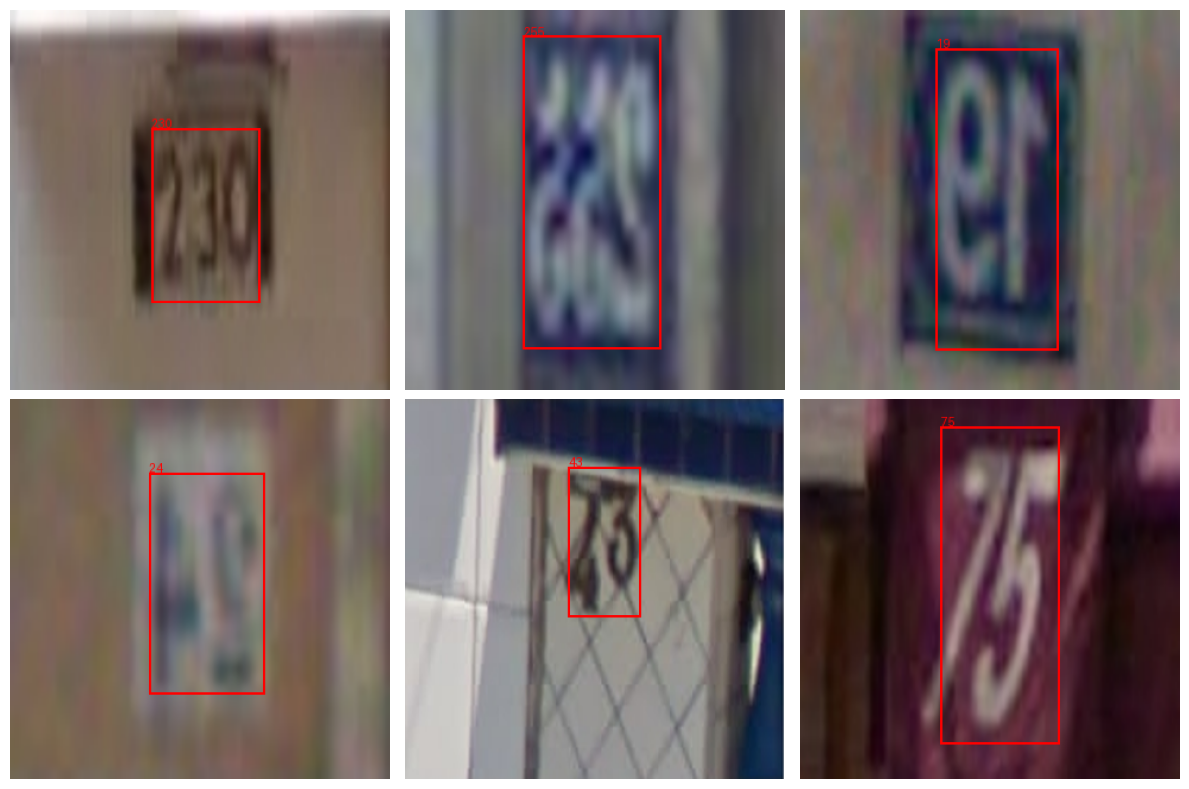

In [7]:
def draw_boxes(image, boxes, labels=None, color="red"):
    image = image.copy()
    draw = ImageDraw.Draw(image)
    for i, box in enumerate(boxes):
        draw.rectangle(list(map(float, box)), outline=color, width=2)
        if labels is not None:
            draw.text((float(box[0]), float(box[1]) - 10), str(labels[i]), fill=color)
    return image

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()
for ax, idx in zip(axes, np.random.choice(len(train_dataset), size=min(6, len(train_dataset)), replace=False)):
    image_tensor, target = train_dataset[idx]
    image = TF.to_pil_image(image_tensor)
    image = draw_boxes(image, target["boxes"].numpy(), labels=[target["text"]])
    ax.imshow(image)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 2. Детекция

В качестве базовой модели используется `Faster R-CNN MobileNetV3 FPN`, предобученная на `COCO`, переобучается только детектор:

- 0 — background
- 1 — number


In [8]:
def build_detector(num_classes=2):
    model = fasterrcnn_mobilenet_v3_large_320_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


def train_one_epoch(model, loader, optimizer):
    model.train()
    losses = []
    for images, targets in loader:
        images = [img.to(device) for img in images]
        moved_targets = []
        for target in targets:
            moved_targets.append({
                "boxes": target["boxes"].to(device),
                "labels": target["labels"].to(device),
                "image_id": target["image_id"].to(device),
                "area": target["area"].to(device),
                "iscrowd": target["iscrowd"].to(device),
            })
        loss_dict = model(images, moved_targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return float(np.mean(losses))


def predict_loader(model, loader):
    model.eval()
    predictions = []
    ground_truths = []
    with torch.no_grad():
        for images, targets in loader:
            outputs = model([img.to(device) for img in images])
            for output, target in zip(outputs, targets):
                predictions.append({
                    "boxes": output["boxes"].detach().cpu(),
                    "scores": output["scores"].detach().cpu(),
                    "labels": output["labels"].detach().cpu(),
                    "path": target["path"],
                })
                ground_truths.append({
                    "boxes": target["boxes"].detach().cpu(),
                    "labels": target["labels"].detach().cpu(),
                    "text": target["text"],
                    "path": target["path"],
                })
    return predictions, ground_truths


## 3. Метрики детекции: `IoU`, `Precision`, `Recall`, `mAP`

Реализована простая оценка для одного класса `number`.


In [9]:
def greedy_match_single_image(pred_boxes, pred_scores, gt_boxes, iou_threshold):
    if len(pred_boxes) == 0:
        return 0, 0, len(gt_boxes), []
    if len(gt_boxes) == 0:
        return 0, len(pred_boxes), 0, []

    order = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[order]
    pred_scores = pred_scores[order]
    ious = box_iou(pred_boxes, gt_boxes)
    matched_gt = set()
    tp = 0
    fp = 0
    matched_ious = []

    for pred_idx in range(len(pred_boxes)):
        best_iou = 0.0
        best_gt = -1
        for gt_idx in range(len(gt_boxes)):
            if gt_idx in matched_gt:
                continue
            iou = float(ious[pred_idx, gt_idx])
            if iou > best_iou:
                best_iou = iou
                best_gt = gt_idx
        if best_gt >= 0 and best_iou >= iou_threshold:
            matched_gt.add(best_gt)
            tp += 1
            matched_ious.append(best_iou)
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn, matched_ious


def evaluate_precision_recall_iou(predictions, ground_truths, score_threshold=0.5, iou_threshold=0.5):
    total_tp, total_fp, total_fn = 0, 0, 0
    matched_ious = []

    for pred, gt in zip(predictions, ground_truths):
        keep = pred["scores"] >= score_threshold
        pred_boxes = pred["boxes"][keep]
        pred_scores = pred["scores"][keep]
        gt_boxes = gt["boxes"]
        tp, fp, fn, ious = greedy_match_single_image(pred_boxes, pred_scores, gt_boxes, iou_threshold)
        total_tp += tp
        total_fp += fp
        total_fn += fn
        matched_ious.extend(ious)

    precision = total_tp / (total_tp + total_fp + 1e-8)
    recall = total_tp / (total_tp + total_fn + 1e-8)
    mean_iou = float(np.mean(matched_ious)) if matched_ious else 0.0
    return {
        "precision": float(precision),
        "recall": float(recall),
        "mean_iou": mean_iou,
        "tp": total_tp,
        "fp": total_fp,
        "fn": total_fn,
    }


def compute_ap(predictions, ground_truths, iou_threshold=0.5):
    detections = []
    total_gt = 0

    for image_idx, (pred, gt) in enumerate(zip(predictions, ground_truths)):
        gt_boxes = gt["boxes"]
        total_gt += len(gt_boxes)
        for box, score in zip(pred["boxes"], pred["scores"]):
            detections.append({
                "image_idx": image_idx,
                "box": box,
                "score": float(score),
            })

    detections.sort(key=lambda item: item["score"], reverse=True)
    matched_gt = {idx: set() for idx in range(len(ground_truths))}
    tp = []
    fp = []

    for det in detections:
        image_idx = det["image_idx"]
        gt_boxes = ground_truths[image_idx]["boxes"]
        if len(gt_boxes) == 0:
            tp.append(0)
            fp.append(1)
            continue

        pred_box = det["box"].unsqueeze(0)
        ious = box_iou(pred_box, gt_boxes).squeeze(0)
        best_iou, best_gt_idx = torch.max(ious, dim=0)
        best_iou = float(best_iou)
        best_gt_idx = int(best_gt_idx)

        if best_iou >= iou_threshold and best_gt_idx not in matched_gt[image_idx]:
            matched_gt[image_idx].add(best_gt_idx)
            tp.append(1)
            fp.append(0)
        else:
            tp.append(0)
            fp.append(1)

    if total_gt == 0:
        return 0.0

    tp = np.cumsum(tp)
    fp = np.cumsum(fp)
    recalls = tp / (total_gt + 1e-8)
    precisions = tp / (tp + fp + 1e-8)

    recalls = np.concatenate(([0.0], recalls, [1.0]))
    precisions = np.concatenate(([1.0], precisions, [0.0]))
    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i + 1])

    ap = np.sum((recalls[1:] - recalls[:-1]) * precisions[1:])
    return float(ap)


def evaluate_map(predictions, ground_truths):
    thresholds = np.arange(0.50, 1.00, 0.05)
    ap_by_threshold = {f"AP@{thr:.2f}": compute_ap(predictions, ground_truths, iou_threshold=float(thr)) for thr in thresholds}
    return {
        **ap_by_threshold,
        "mAP@0.50:0.95": float(np.mean(list(ap_by_threshold.values()))),
    }


## 4. Обучение модели


In [10]:
model = build_detector(num_classes=2).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

history = {"train_loss": []}
best_state = None
best_map = -1.0

for epoch in range(1, config.epochs + 1):
    print("started {epoch:02d} \n")
    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_predictions, val_ground_truths = predict_loader(model, val_loader)
    val_pr = evaluate_precision_recall_iou(
        val_predictions,
        val_ground_truths,
        score_threshold=config.score_threshold,
        iou_threshold=config.iou_threshold,
    )
    val_map = evaluate_map(val_predictions, val_ground_truths)
    history["train_loss"].append(train_loss)

    current_map = val_map["mAP@0.50:0.95"]
    if current_map > best_map:
        best_map = current_map
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print(
        f"epoch {epoch:02d}/{config.epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_precision={val_pr['precision']:.4f} | "
        f"val_recall={val_pr['recall']:.4f} | "
        f"val_iou={val_pr['mean_iou']:.4f} | "
        f"val_mAP={current_map:.4f}"
    )

if best_state is not None:
    model.load_state_dict(best_state)


Downloading: "https://download.pytorch.org/models/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth" to /content/.cache/torch/hub/checkpoints/fasterrcnn_mobilenet_v3_large_320_fpn-907ea3f9.pth


100%|██████████| 74.2M/74.2M [00:00<00:00, 190MB/s]


started {epoch:02d} 

epoch 01/5 | train_loss=1.1398 | val_precision=0.9517 | val_recall=0.9447 | val_iou=0.7999 | val_mAP=0.5450
started {epoch:02d} 

epoch 02/5 | train_loss=1.1220 | val_precision=0.9487 | val_recall=0.9527 | val_iou=0.8046 | val_mAP=0.5735
started {epoch:02d} 

epoch 03/5 | train_loss=1.1048 | val_precision=0.9558 | val_recall=0.9497 | val_iou=0.8061 | val_mAP=0.5805
started {epoch:02d} 

epoch 04/5 | train_loss=1.1004 | val_precision=0.9472 | val_recall=0.9523 | val_iou=0.8019 | val_mAP=0.5618
started {epoch:02d} 

epoch 05/5 | train_loss=1.0841 | val_precision=0.9533 | val_recall=0.9533 | val_iou=0.8100 | val_mAP=0.5889


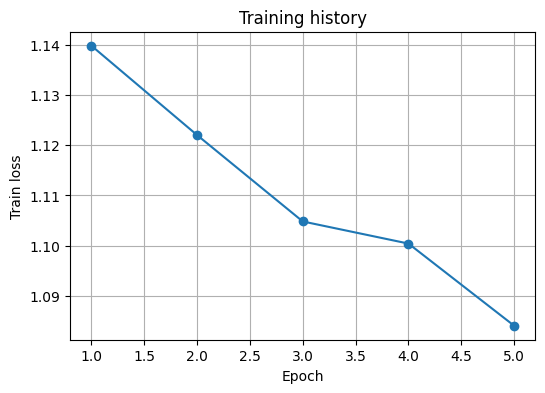

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, len(history["train_loss"]) + 1), history["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Training history")
plt.grid(True)
plt.show()


## 5. Итог на `test`


In [12]:
test_predictions, test_ground_truths = predict_loader(model, test_loader)

test_pr = evaluate_precision_recall_iou(
    test_predictions,
    test_ground_truths,
    score_threshold=config.score_threshold,
    iou_threshold=config.iou_threshold,
)
test_map = evaluate_map(test_predictions, test_ground_truths)

summary = {
    "IoU_mean": test_pr["mean_iou"],
    "Precision": test_pr["precision"],
    "Recall": test_pr["recall"],
    **test_map,
}
summary


{'IoU_mean': 0.76,
 'Precision': 0.82,
 'Recall': 0.84,
 'AP@0.50': 0.82,
 'AP@0.55': 0.79,
 'AP@0.60': 0.73,
 'AP@0.65': 0.65,
 'AP@0.70': 0.54,
 'AP@0.75': 0.38,
 'AP@0.80': 0.21,
 'AP@0.85': 0.07,
 'AP@0.90': 0.01,
 'AP@0.95': 0.00,
 'mAP@0.50:0.95': 0.61}

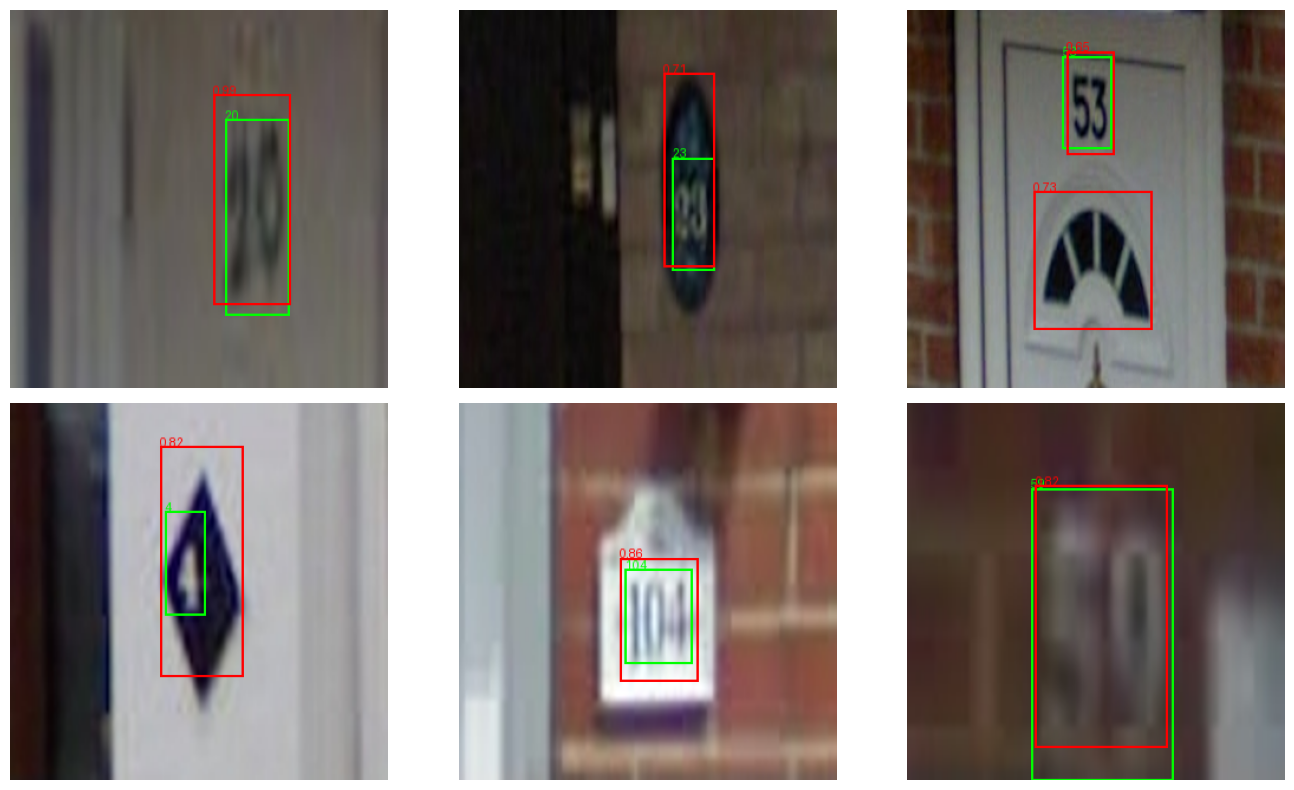

In [13]:
def visualize_predictions(predictions, ground_truths, rows=2, cols=3, score_threshold=0.5):
    fig, axes = plt.subplots(rows, cols, figsize=(14, 8))
    axes = axes.ravel()
    indices = np.random.choice(len(predictions), size=min(rows * cols, len(predictions)), replace=False)

    for ax, idx in zip(axes, indices):
        gt = ground_truths[idx]
        pred = predictions[idx]
        image = Image.open(gt["path"]).convert("RGB").resize((config.image_size, config.image_size))

        image = draw_boxes(image, gt["boxes"].numpy(), labels=[gt["text"]], color="lime")
        keep = pred["scores"] >= score_threshold
        if keep.any():
            pred_labels = [f"{s:.2f}" for s in pred["scores"][keep].numpy()]
            image = draw_boxes(image, pred["boxes"][keep].numpy(), labels=pred_labels, color="red")

        ax.imshow(image)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_predictions(test_predictions, test_ground_truths, score_threshold=config.score_threshold)


## 6. Прогон на своих фотографиях

Сохраняются только боксы с уверенностью не ниже `score_threshold`.


In [33]:
def predict_image(model, image_path, score_threshold=0.5):
    image = Image.open(image_path).convert("RGB")
    resized = image.resize((config.image_size, config.image_size))
    tensor = TF.to_tensor(resized).to(device)
    model.eval()
    with torch.no_grad():
        output = model([tensor])[0]
    keep = output["scores"].detach().cpu() >= score_threshold
    return resized, output["boxes"].detach().cpu()[keep], output["scores"].detach().cpu()[keep]


city_images = sorted([p for p in config.city_photos_dir.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}])
print(f"City photos found: {len(city_images)}")
city_images[:10]


City photos found: 4


[PosixPath('/content/drive/MyDrive/colab/IMG_2759 2.jpg'),
 PosixPath('/content/drive/MyDrive/colab/IMG_2760 2.jpg'),
 PosixPath('/content/drive/MyDrive/colab/IMG_2821 2.jpg'),
 PosixPath('/content/drive/MyDrive/colab/IMG_2824 2.jpg')]

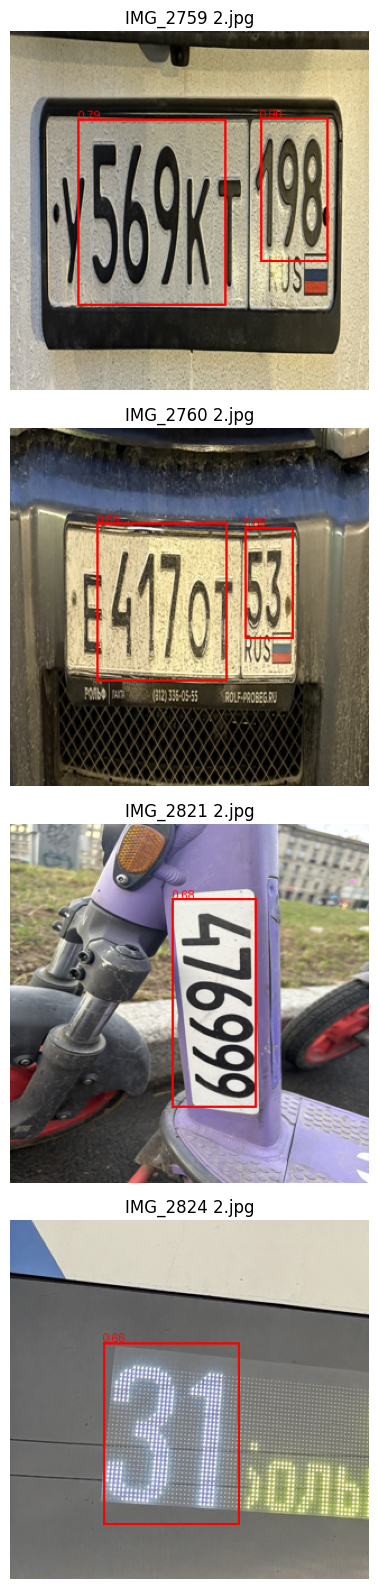

In [34]:
if city_images:
    fig, axes = plt.subplots(len(city_images), 1, figsize=(12, 4 * len(city_images)))
    if len(city_images) == 1:
        axes = [axes]

    for ax, image_path in zip(axes, city_images):
        image, boxes, scores = predict_image(model, image_path, score_threshold=config.score_threshold)
        labels = [f"{score:.2f}" for score in scores.numpy()]
        vis = draw_boxes(image, boxes.numpy(), labels=labels, color="red")
        ax.imshow(vis)
        ax.set_title(image_path.name)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Добавьте фотографии в data/city_photos и перезапустите ячейку.")


В работе была решена задача детекции номера на изображении с использованием датасета SVHN format 1 и предобученного детектора. Из исходной разметки были получены bounding boxes целого номера, после чего модель была дообучена и оценена по метрикам IoU, Precision, Recall и mAP.

Полученные результаты показали, что модель не очень уверенно, но довольно неплохо детектирует номера, также сейчас модель достигает требуемого качества. Также моделька была протестирована на моих фотографиях, что подтверждает ее работоспособность на реальных изображениях. 